In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [44]:
df_raw=pd.read_csv("mtcars.csv")
df=df_raw.copy()
print("First 5 rows:")
print(df.head())
print("Data types")
print(df.dtypes)
print("Info")
print(df.info())

First 5 rows:
               model   mpg  cyl   disp   hp  drat     wt   qsec  vs  am  gear  \
0          Mazda RX4  21.0    6  160.0  110  3.90  2.620  16.46   0   1     4   
1      Mazda RX4 Wag  21.0    6  160.0  110  3.90  2.875  17.02   0   1     4   
2         Datsun 710  22.8    4  108.0   93  3.85  2.320  18.61   1   1     4   
3     Hornet 4 Drive  21.4    6  258.0  110  3.08  3.215  19.44   1   0     3   
4  Hornet Sportabout  18.7    8  360.0  175  3.15  3.440  17.02   0   0     3   

   carb  
0     4  
1     4  
2     1  
3     1  
4     2  
Data types
model        str
mpg      float64
cyl        int64
disp     float64
hp         int64
drat     float64
wt       float64
qsec     float64
vs         int64
am         int64
gear       int64
carb       int64
dtype: object
Info
<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   model   32 non-null     str    
 1

In [45]:
summary=df[["mpg","hp","wt"]].agg(["mean","median","min","max"])
print("Summary Statistics")
print(summary.round(2))

Summary Statistics
          mpg      hp    wt
mean    20.09  146.69  3.22
median  19.20  123.00  3.32
min     10.40   52.00  1.51
max     33.90  335.00  5.42


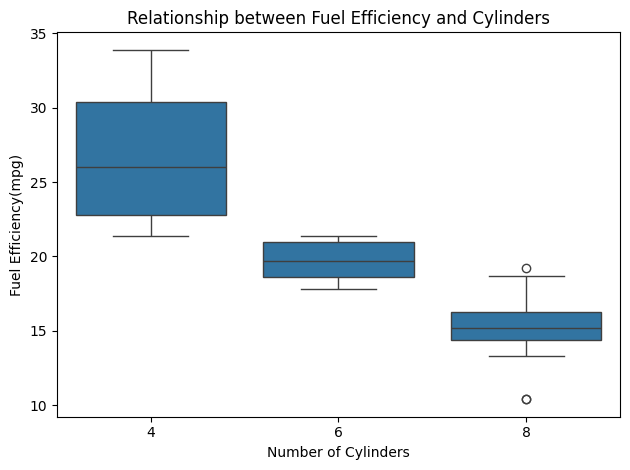

In [46]:
sns.boxplot(x='cyl',y='mpg',data=df)
plt.title("Relationship between Fuel Efficiency and Cylinders")
plt.xlabel("Number of Cylinders")
plt.ylabel("Fuel Efficiency(mpg)")
plt.tight_layout()
plt.show()

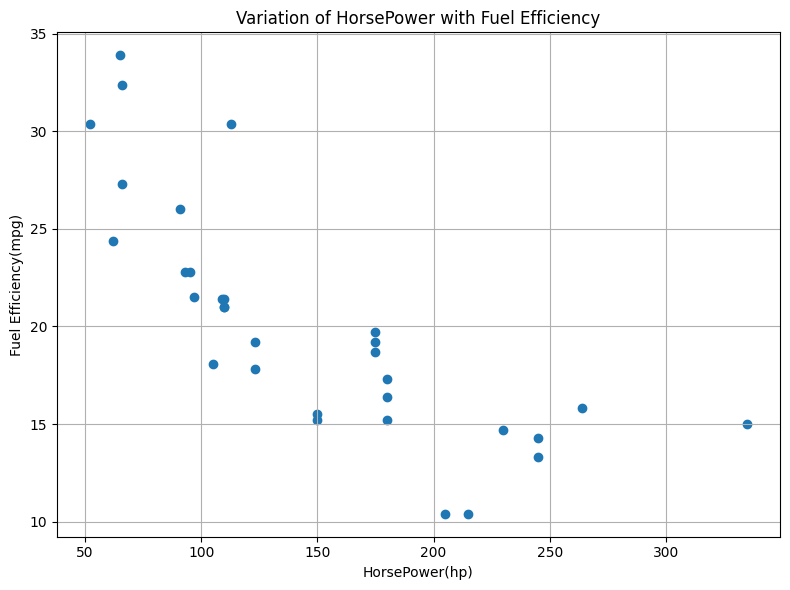

In [47]:
plt.figure(figsize=(8,6))
plt.scatter(df['hp'],df['mpg'])
plt.title("Variation of HorsePower with Fuel Efficiency")
plt.xlabel("HorsePower(hp)")
plt.ylabel("Fuel Efficiency(mpg)")
plt.grid()
plt.tight_layout()
plt.show()

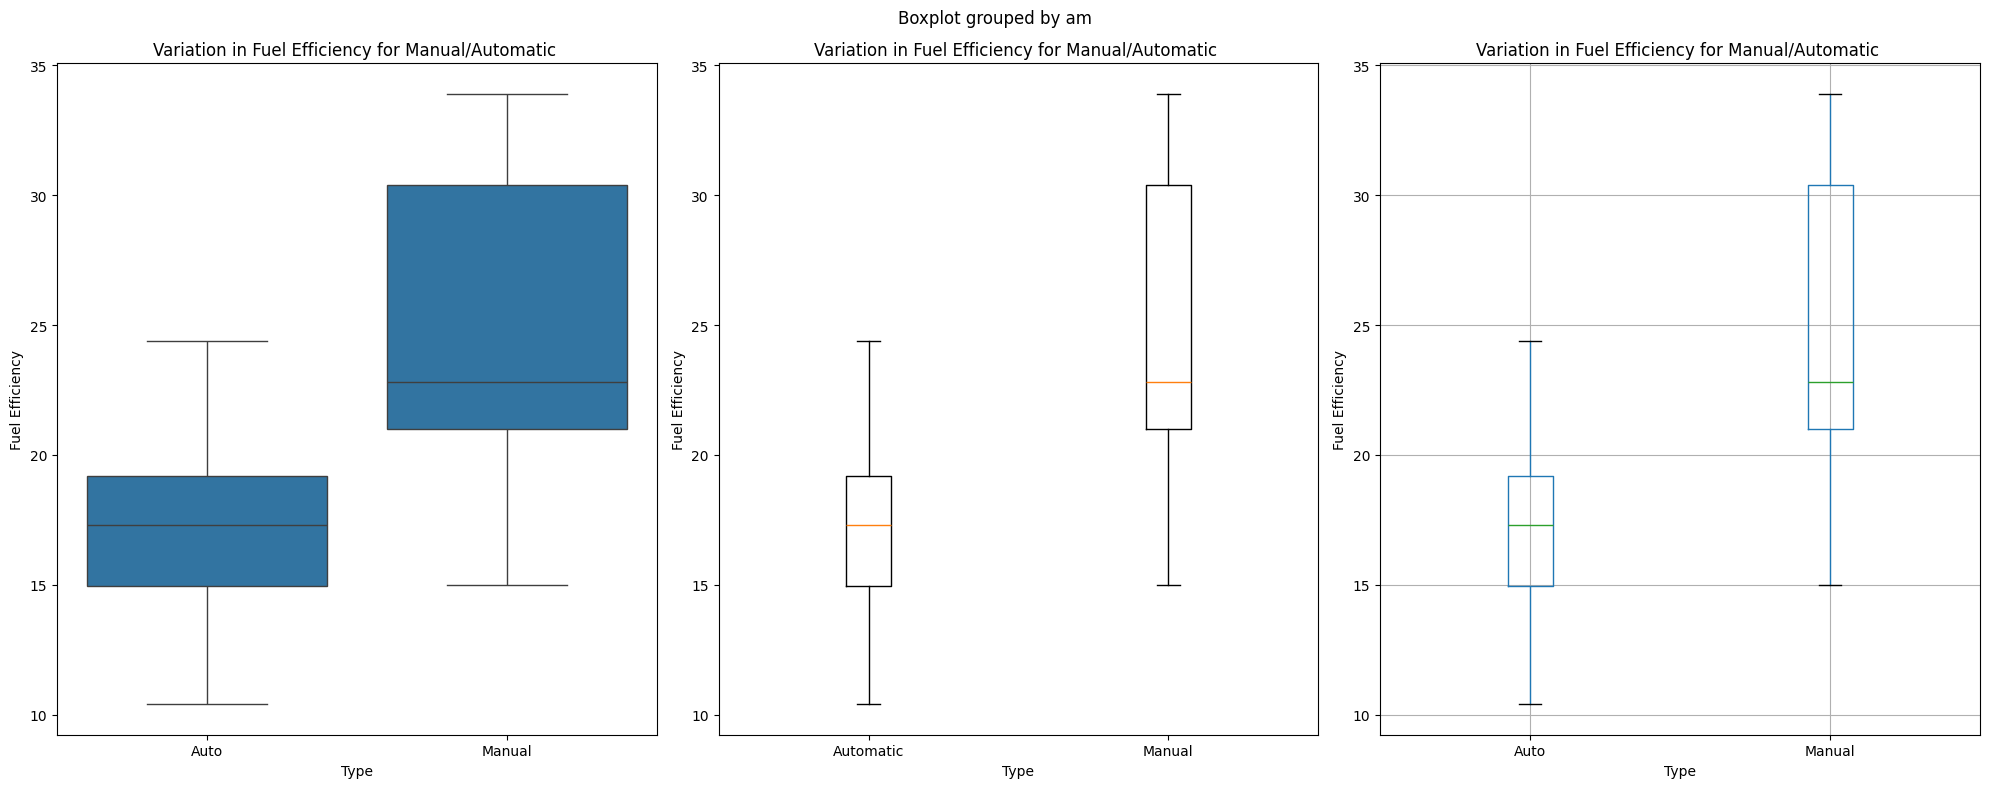

In [48]:
plt.figure(figsize=(20,8))
plt.subplot(1,3,1)
sns.boxplot(x='am',y='mpg',data=df)
plt.title("Variation in Fuel Efficiency for Manual/Automatic ")
plt.xlabel("Type")
plt.xticks([0,1],['Auto','Manual'])
plt.ylabel("Fuel Efficiency")
plt.tight_layout()

plt.subplot(1,3,2)
auto_mpg=df[df['am']==0]['mpg']
manual_mpg=df[df['am']==1]['mpg']
plt.boxplot([auto_mpg,manual_mpg],tick_labels=['Automatic','Manual'],)
plt.title("Variation in Fuel Efficiency for Manual/Automatic ")
plt.xlabel("Type")
plt.ylabel("Fuel Efficiency")
plt.tight_layout()

plt.subplot(1,3,3)
df.boxplot(column='mpg',by='am',ax=plt.gca())
plt.title("Variation in Fuel Efficiency for Manual/Automatic ")
plt.xlabel("Type")
ax=plt.gca()
ax.set_xticklabels(['Auto','Manual'])
plt.ylabel("Fuel Efficiency")
plt.tight_layout()
plt.show()


In [59]:
print(df.loc[df['mpg'] > 25])

             model   mpg  cyl   disp   hp  drat     wt   qsec  vs  am  gear  \
17        Fiat 128  32.4    4   78.7   66  4.08  2.200  19.47   1   1     4   
18     Honda Civic  30.4    4   75.7   52  4.93  1.615  18.52   1   1     4   
19  Toyota Corolla  33.9    4   71.1   65  4.22  1.835  19.90   1   1     4   
25       Fiat X1-9  27.3    4   79.0   66  4.08  1.935  18.90   1   1     4   
26   Porsche 914-2  26.0    4  120.3   91  4.43  2.140  16.70   0   1     5   
27    Lotus Europa  30.4    4   95.1  113  3.77  1.513  16.90   1   1     5   

    carb  
17     1  
18     2  
19     1  
25     1  
26     2  
27     2  


avg_hp: 146.6875
threshold: 102.68124999999999
     hp   mpg
17   66  32.4
18   52  30.4
19   65  33.9
25   66  27.3
26   91  26.0
27  113  30.4
             model   hp   mpg
0        Mazda RX4  110  21.0
1    Mazda RX4 Wag  110  21.0
2       Datsun 710   93  22.8
3   Hornet 4 Drive  110  21.4
8         Merc 230   95  22.8
20   Toyota Corona   97  21.5
26   Porsche 914-2   91  26.0
27    Lotus Europa  113  30.4
31      Volvo 142E  109  21.4


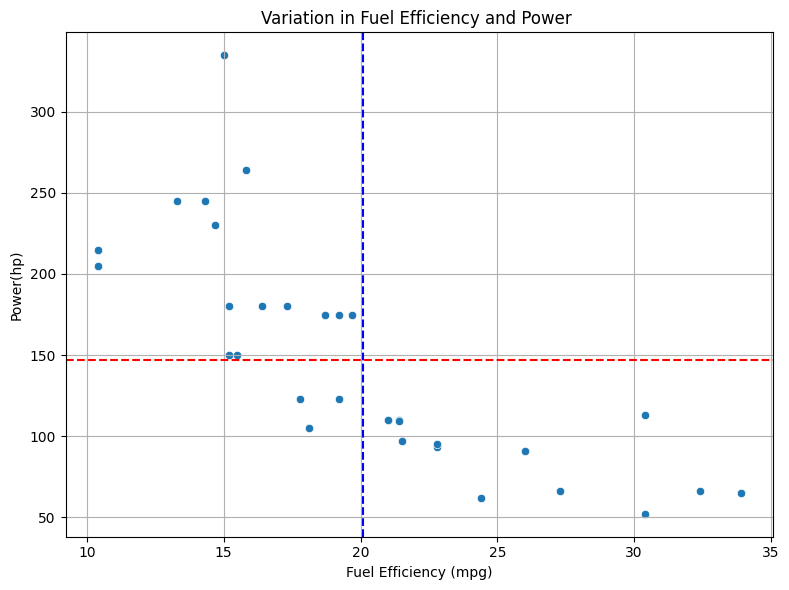

In [61]:
avg_hp=df['hp'].mean()
avg_mpg=df['mpg'].mean()
print("avg_hp:", avg_hp)
print("threshold:", avg_hp * 0.7)
print(df.loc[df['mpg'] > 25][['hp','mpg']])
balanced_cars=df[((df['hp']>avg_hp*0.6) & (df['mpg']>avg_mpg))]
print(balanced_cars[['model','hp','mpg']])
plt.figure(figsize=(8,6))
sns.scatterplot(x='mpg',y='hp',data=df)
plt.title("Variation in Fuel Efficiency and Power ")
plt.axhline(avg_hp, color='red', linestyle='--', label='Average HP')
plt.axvline(avg_mpg, color='blue', linestyle='--', label='Average MPG')
plt.xlabel("Fuel Efficiency (mpg)")
plt.ylabel("Power(hp)")
plt.grid()
plt.tight_layout()
plt.show()